S2 is a geometry library that represents the surface of the Earth (and other spheres) using a hierarchy of cells
https://s2geometry.io/devguide/s2cell_hierarchy.html  
Key ideas:
- sphere is projected onto the six faces of a cube, and each face is recursively subdivided into four child cells (a quadtree)
- every cell has a unique integer CellId and a compact token representation
- cells are indexed through hilbert curve
- cell level controls resolution
- low levels are very large cells (entire continents)
- high levels are small (tens of meters or less)
- cells live on the sphere - areas are more uniform and behavior near the poles is better than planar lat-lon grids


# Imports - Basic

In [3]:
import math
import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from dataclasses import dataclass
from typing import Dict, List, Tuple
import folium
from IPython.display import display
import plotly.graph_objects as go

# Comparison

these are 3 popular spatial indexing systems - all let you map (lat, lon) -> a cell id, but they differ in what surface they discretize and therefore what kinds of distortion they introduce:

- **Geohash** - divides the map into a standard grid, but the physical size of the grid shrinks at the poles
  - recursive subdivision in lat/lon space (a rectangular grid in degrees)
  - uniform in degrees (not in meters)
  - cell shapes are rectangles in (lat, lon) 
  - their physical width shrinks toward the poles
  - uses a Z-order curve https://en.wikipedia.org/wiki/Z-order_curve
  - outputs a base-32 string
  - prefix matching - same prefix - closer - allows spatial clustering by text match
  - each level is 32

- **H3** - maps the Earth to an icosahedron (20 faces) covered in hexagons
  - discretize the sphere using an icosahedron and mostly hexagonal cells (with a small number of pentagons)
  - Hexagons give strong neighborhood properties (k-rings, local adjacency).
  - Distortion exists (as its on a sphere), but is spread relatively evenly
  - Great for “grid math” (neighbors, rings, disks) with mostly uniform cells
  - because distance from center is identical
  - popular for spatial smooting, radius and routing (developed by Uber) - https://h3geo.org/docs
  - each level is 7

- **S2** - maps the earth to a cube, then projects it onto a sphere, subdivide cube faces, then project back to the sphere
  - cells are quadrilateral-ish on the sphere
  - efficient hierarchical indexing 
  - distortion is bounded and well-behave globally
  - Great for hierarchy with predictable parent/child relationships
  - uses a hilbert space curve https://s2geometry.io/devguide/s2cell_hierarchy.html
  - very fast because maps to 64bit integers
  - each level is 4

In [5]:
from s2sphere import Angle, Cap, CellId, LatLng, RegionCoverer, LatLngRect

import s2sphere as s2
import geohash2 as geohash
# import pygeohash as geohash
import h3

In [6]:
# Gatineau/Ottawa coordinates
lat, lon = 45.428, -75.718
EARTH_RADIUS_M = 6371000

## Size & Precision

**Geohash**
- 1 to 12 resolution
- 12 characters 
- base 32 string - every character is 5bit worth of precision - so exponential change in levels
- Z curve indexing to divide further on each level
- level 1 - first division - 8 columns (ie 360/8 = 45 degree lon), 4 rows (ie 180/4 = 45 degree lat) = 5000x5000km
- level 4 - 39 km (metropolitan), level 5 - 5km (city), level 6 - 1.2km (neighborhood)
- level 12 - 3.7cm * 1.8cm
- in reactangle distance center to its diagonal neighbors is $\sqrt{2}$

**H3**
- distance from the center of a cell to its vertical/horizontal neighbors and diagonal neighbor is 1
- distance to its diagonal neighbors is $\sqrt{2}$
- aperture 7 system - each part into 7 smaller parts
- sphere -> hexagons, 12 pentagons in between (also sub hierarchy not perfectly contained)
- 0 to 15 resolution, where 1 edge of hexagon:
- level 0 ~ 1100km (continental), level 3 ~ 60km (state), level 5 ~ 8.5km (city), level 7 ~ 1.2km (neighborhood)
- level 15 ~ 0.5m 

**S2**
- projects earth to cube - cube is level 0 (cell at 0 = 1/6 earth)
- quad tree hierarchy - every cell can be perfectly subdivided to 4 smaller cells 
- indexed through hilbert curve - continuous (unike z curve of geohash which can jump across)
- 64 bit integer for every cell - fast operations
- 0 to 30 resolution, where 1 edge of the cube
- level 0 ~ 10k km, level 4 ~ 576 km (country), level 10 ~ 9 km (city), level 13 ~ 1 km (neighborhood)
- level 20 ~ 8m (house), level 24 ~ 55 cm, level 30 ~ 0.9 cm

In [7]:
levels = {
    # "neighborhood":{"geohash": 6,"h3": 7,"s2": 13},
    "smallest":{"geohash": 12, "h3": 15, "s2": 30},
    "largest":{"geohash": 1, "h3": 0, "s2": 0}, # in geohash 0 is the whole world 
    "state": {"geohash": 3, "h3": 2, "s2": 6}, # 100,000+ km2 (State / Province Level)
    "metro": {"geohash": 4, "h3": 4, "s2": 8}, # 500+ km2 (Wide Metro Area / County Level)
    # "city" :{"geohash": 5, "h3": 5, "s2": 10},
    "city": {"geohash": 5, "h3": 6, "s2": 11}, #16 - 40 km2 (City Ward / Large District) 
    "neighborhood": {"geohash": 6, "h3": 7, "s2": 12}, #5 km2 (Neighborhood),
    "sentinel_scale": {"geohash": 8, "h3": 12, "s2": 20} #10m approx
}

In [8]:
selected_level = "city"
config = levels[selected_level]

print(f"SPATIAL METADATA FOR LEVEL: '{selected_level.upper()}'")
print(f"Lat: {lat}, Lon: {lon} \n")

# GEOHASH
gh = geohash.encode(lat, lon, precision=config['geohash'])
gh_parent = geohash.encode(lat, lon, precision=config['geohash'] - 1) if config['geohash'] > 1 else "None"
lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(gh)
# approx. area = width * height in meters
gh_width_m = (lon_err * 2) * (math.cos(math.radians(lat_c)) * 111320)
gh_height_m = (lat_err * 2) * 111320
gh_area_sqm = gh_width_m * gh_height_m

print(f"GEOHASH (Precision {config['geohash']})")
print(f"  Token:     {gh}")
print(f"  Parent:    {gh_parent}")
print(f"  Centroid:  {lat_c:.6f}, {lon_c:.6f}")
print(f"  Edge:      {gh_width_m:.2f}m x {gh_height_m:.2f}m")
print(f"  Est. Area: ~{gh_area_sqm:.4f} m²\n")

# H3 
print(f"H3 (Resolution {config['h3']})")
h3_index = h3.latlng_to_cell(lat, lon, config['h3'])
h3_parent = h3.cell_to_parent(h3_index, config['h3'] - 1) if config['h3'] > 0 else "None"
h3_lat, h3_lon = h3.cell_to_latlng(h3_index)
# Get the directed edges of this cell, then measure the first one in meters
h3_edges = h3.origin_to_directed_edges(h3_index)
h3_edge_m = h3.edge_length(h3_edges[0], unit='m') 
h3_area = h3.cell_area(h3_index, unit='m^2')

print(f"  Token:     {h3_index}")
print(f"  Parent:    {h3_parent}")
print(f"  Centroid:  {h3_lat:.6f}, {h3_lon:.6f}")
print(f"  Edge:      {h3_edge_m:.4f}m")
print(f"  Est. Area: ~{h3_area:.4f} m²\n")

# S2 
p = s2.LatLng.from_degrees(lat, lon)
s2_target_id = s2.CellId.from_lat_lng(p).parent(config['s2'])
s2_parent_id = s2_target_id.parent(config['s2'] - 1) if config['s2'] > 0 else "None"
s2_cell = s2.Cell(s2_target_id)
s2_center = s2.LatLng.from_point(s2_cell.get_center())
# area = steradians * R^2
s2_area_sqm = s2_cell.exact_area() * (EARTH_RADIUS_M ** 2)
# edge = Angle between Vertex 0 and Vertex 1 * R
v0 = s2_cell.get_vertex(0)
v1 = s2_cell.get_vertex(1)
s2_edge_m = v0.angle(v1) * EARTH_RADIUS_M

print(f"S2 (Level {config['s2']})")
print(f"  Token:     {s2_target_id.to_token()}")
print(f"  Parent:    {s2_parent_id.to_token() if s2_parent_id != 'None' else 'None'}")
print(f"  Centroid:  {s2_center.lat().degrees:.6f}, {s2_center.lng().degrees:.6f}")
print(f"  Edge:      {s2_edge_m:.4f}m")
print(f"  Est. Area: ~{s2_area_sqm:.4f} m²")

SPATIAL METADATA FOR LEVEL: 'CITY'
Lat: 45.428, Lon: -75.718 

GEOHASH (Precision 5)
  Token:     f244k
  Parent:    f244
  Centroid:  45.417480, -75.739746
  Edge:      3433.86m x 4891.99m
  Est. Area: ~16798437.7513 m²

H3 (Resolution 6)
  Token:     862b83b1fffffff
  Parent:    852b83b3fffffff
  Centroid:  45.419360, -75.762752
  Edge:      3950.1645m
  Est. Area: ~39265300.7201 m²

S2 (Level 11)
  Token:     4cce04c
  Parent:    4cce05
  Centroid:  45.443463, -75.710880
  Edge:      3828.7976m
  Est. Area: ~16085576.0171 m²


## Visualize Single cell

In [9]:
def get_cell(lat, lon, selected_level):
    config = levels[selected_level]

    # --- GEOHASH ---
    gh = geohash.encode(lat, lon, precision=config['geohash'])
    lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(gh)
    n, s = lat_c + lat_err, lat_c - lat_err
    e, w = lon_c + lon_err, lon_c - lon_err
    gh_vertices = [[s, w], [s, e], [n, e], [n, w]]

    # --- H3 ---
    h3_index = h3.latlng_to_cell(lat, lon, config['h3'])
    h3_vertices = [list(coord) for coord in h3.cell_to_boundary(h3_index)]
    h3_lat, h3_lon = h3.cell_to_latlng(h3_index)

    # --- S2 ---
    s2_point = s2.LatLng.from_degrees(lat, lon)
    s2_target_id = s2.CellId.from_lat_lng(s2_point).parent(config['s2'])
    s2_cell = s2.Cell(s2_target_id)
    s2_vertices = [[
        s2.LatLng.from_point(s2_cell.get_vertex(i)).lat().degrees,
        s2.LatLng.from_point(s2_cell.get_vertex(i)).lng().degrees
    ] for i in range(4)]
    s2_center = s2.LatLng.from_point(s2_cell.get_center())

    return {
        "geohash": {
            "token": gh,
            "centroid": [lat_c, lon_c],
            "vertices": gh_vertices
        },
        "h3": {
            "token": h3_index,
            "centroid": [h3_lat, h3_lon],
            "vertices": h3_vertices
        },
        "s2": {
            "token": s2_target_id.to_token(),
            "centroid": [s2_center.lat().degrees, s2_center.lng().degrees],
            "vertices": s2_vertices
        }
    }

In [10]:
def plot_cell(selected_level, result):
    
    # OSM
    m = folium.Map(location=[lat, lon], tiles="OpenStreetMap")
    folium.Marker([lat, lon], popup="Target Location", icon=folium.Icon(color="black")).add_to(m)

    gh_token = result["geohash"]["token"]
    h3_token = result["h3"]["token"]
    s2_token = result["s2"]["token"]

    # Geohash
    fg_gh = folium.FeatureGroup(name=f"Geohash ({gh_token})").add_to(m)
    gh_vertices = result["geohash"]["vertices"]
    folium.Polygon(locations=gh_vertices, color='blue', fill=True, fill_opacity=0.2).add_to(fg_gh)

    # H3
    fg_h3 = folium.FeatureGroup(name=f"H3 ({h3_token})").add_to(m)
    h3_vertices = result["h3"]["vertices"]
    folium.Polygon(locations=h3_vertices, color='green', fill=True, fill_opacity=0.2).add_to(fg_h3)

    # S2
    fg_s2 = folium.FeatureGroup(name=f"S2 ({s2_token})").add_to(m)
    s2_vertices = result["s2"]["vertices"]
    folium.Polygon(locations=s2_vertices, color='red', fill=True, fill_opacity=0.2).add_to(fg_s2)

    # map to automatically snap to the H3 boundary
    m.fit_bounds(h3_vertices)

    folium.LayerControl().add_to(m)

    return m


In [11]:
result_city = get_cell(lat, lon,selected_level="city")
map = plot_cell(selected_level="city", result=result_city)
display(map)

## Distance

In [12]:
import math

### Geodesic

Point 1: $(\phi_1, \lambda_1)$ , Point 2: $(\phi_2, \lambda_2)$  
$\phi$ = latitude (radians), $\lambda$ = longitude (radians), $R$ = Earth radius  
$\Delta \phi = \phi_2 - \phi_1$, $\Delta \lambda = \lambda_2 - \lambda_1$

Haversine:
$a = \sin^2\left(\frac{\Delta \phi}{2}\right)+ \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta \lambda}{2}\right)$

Angular Distance:
$c = 2 \cdot \arctan2\left(\sqrt{a}, \sqrt{1-a}\right)$

Final Distance:
$d = R \cdot c$

In [13]:
def haversine_dist_m(lat1, lon1, lat2, lon2, R=EARTH_RADIUS_M):
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi / 2.0) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2.0) ** 2 
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

### Planar

Point 1: $(\phi_1, \lambda_1)$ , Point 2: $(\phi_2, \lambda_2)$  
$\phi$ = latitude (radians), $\lambda$ = longitude (radians), $R$ = Earth radius  

Reference point $(\phi_0, \lambda_0)$  

Projection Center (reduce distortion):   
$\phi_0 = \frac{\phi_1 + \phi_2}{2}$
$\lambda_0 = \frac{\lambda_1 + \lambda_2}{2}$

Equirectangular Projection :  

east-west displacement in meters    
$x = R \cdot (\lambda - \lambda_0) \cdot \cos(\phi_0)$  
$\cos(\phi_0)$ term corrects for the fact that lines of longitude
get closer together toward the poles  

north-south displacement in meters  
$y = R \cdot (\phi - \phi_0)$




Euclidean Distance in Projected Space (m) :

$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

In [14]:
def project_equi_rect_m(lat, lon, lat0, lon0, R=EARTH_RADIUS_M):
    x = R * math.radians(lon - lon0) * math.cos(math.radians(lat0))
    y = R * math.radians(lat - lat0)
    return x, y

In [15]:
def euclidean_m_xy(x1, y1, x2, y2):
    return math.hypot(x2 - x1, y2 - y1)

In [16]:
def euclidean_dist_m(lat1, lon1, lat2, lon2, lat0=None, lon0=None):
    if lat0 is None: lat0 = (lat1 + lat2) / 2
    if lon0 is None: lon0 = (lon1 + lon2) / 2
    x1, y1 = project_equi_rect_m(lat1, lon1, lat0, lon0)
    x2, y2 = project_equi_rect_m(lat2, lon2, lat0, lon0)
    return euclidean_m_xy(x1, y1, x2, y2)

### Point to point

#### Test pairs

In [17]:
test_pairs = {
    "local": [(45.428, -75.718), (45.47, -75.70)], #(Ottawa ~5km)
    "regional": [(45.428, -75.718), (45.5017, -73.5673)], #(Ottawa–Montreal)
    "cross_country": [(45.428, -75.718), (49.2827, -123.1207)], #(Ottawa–Vancouver)
    "equator": [(0.0, 0.0), (0.0, 10.0)], #(0°, 0° - 0°, 10°)
    "poles": [(70.0, 0.0), (70.0, 60.0)], #(70°, 0° - 70°, 60°)
}

##### Visualize

In [18]:
def latlon_to_xyz(lat, lon):
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    return np.array([np.cos(lat_r)*np.cos(lon_r), np.cos(lat_r)*np.sin(lon_r), np.sin(lat_r)])

def slerp(p0, p1, t):
    dot = np.clip(np.sum(p0 * p1), -1.0, 1.0)
    omega = np.arccos(dot)
    so = np.sin(omega)
    return p0 if so == 0 else np.sin((1.0 - t)*omega)/so * p0 + np.sin(t*omega)/so * p1

def xyz_to_latlon(v):
    v = v / np.linalg.norm(v)
    return np.degrees(np.arcsin(v[2])), np.degrees(np.arctan2(v[1], v[0]))

fig = go.Figure()
colors = ['purple', 'orange', 'green', 'magenta', 'red']

for idx, (name, pair) in enumerate(test_pairs.items()):
    lat1, lon1 = pair[0]
    lat2, lon2 = pair[1]
    c = colors[idx % len(colors)]
    
    # Calculate 50 points along the true Geodesic (Spherical) path
    v1, v2 = latlon_to_xyz(lat1, lon1), latlon_to_xyz(lat2, lon2)
    geo_lats, geo_lons = zip(*[xyz_to_latlon(slerp(v1, v2, t)) for t in np.linspace(0, 1, 50)])
    
    # Calculate 50 points along the Planar (Flat map linear interpolation) path
    plan_lats = np.linspace(lat1, lat2, 50)
    plan_lons = np.linspace(lon1, lon2, 50)

    # Add Points
    fig.add_trace(go.Scattergeo(
        lat=[lat1, lat2], lon=[lon1, lon2],
        mode='markers', marker=dict(size=8, color=c),
        name=f"{name.title()} Points", showlegend=False
    ))

    # Add Geodesic Line (Solid)
    fig.add_trace(go.Scattergeo(
        lat=geo_lats, lon=geo_lons,
        mode='lines', line=dict(width=3, color=c),
        name=f"{name.title()} (Geodesic)"
    ))

    # Add Planar Line (Dashed)
    fig.add_trace(go.Scattergeo(
        lat=plan_lats, lon=plan_lons,
        mode='lines', line=dict(width=3, color=c, dash='dash'),
        name=f"{name.title()} (Planar)"
    ))

fig.update_layout(
    title="Interactive Globe: Geodesic vs. Planar Paths",
    geo=dict(
        projection_type="orthographic", # Creates the 3D globe effect
        showland=True, landcolor="rgb(240, 240, 240)",
        showocean=True, oceancolor="rgb(200, 230, 255)",
        showcountries=True, countrycolor="white",
        projection_rotation=dict(lon=-60, lat=45, roll=0) # Centers on North America/Atlantic
    ),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

#### Geometry comparison

In [19]:
def compare_geometries_dist(lat1, lon1, lat2, lon2, selected_level='medium'):

    print(f"\nComparing at '{selected_level.upper()}' level\n")

    # True distances
    d_geo = haversine_dist_m(lat1, lon1, lat2, lon2)
    d_planar = euclidean_dist_m(lat1, lon1, lat2, lon2)

    print("=== True Distances ===")
    print("Geodesic distance (m):", round(d_geo, 2))
    print("Planar distance (m):  ", round(d_planar, 2))
    print("Absolute difference (m):", round(abs(d_geo - d_planar), 2))
    print("Percent difference (%):", round(100 * abs(d_geo - d_planar)/d_geo, 4))

    # Cells for each point
    cell1 = get_cell(lat1, lon1, selected_level)
    cell2 = get_cell(lat2, lon2, selected_level)

    results = []

    print("\n=== Geometry System Comparison ===")

    for system in ['geohash', 'h3', 's2']:

        lat_c1, lon_c1 = cell1[system]['centroid']
        lat_c2, lon_c2 = cell2[system]['centroid']

        d_centroid_geo = haversine_dist_m(lat_c1, lon_c1, lat_c2, lon_c2)
        d_centroid_planar = euclidean_dist_m(lat_c1, lon_c1, lat_c2, lon_c2)

        error_geo = abs(d_geo - d_centroid_geo)

        print(f"\n--- {system.upper()} ---")
        print("Token 1:", cell1[system]['token'])
        print("Token 2:", cell2[system]['token'])
        print("Centroid Geodesic (m):", round(d_centroid_geo, 2))
        print("Centroid Planar (m):  ", round(d_centroid_planar, 2))
        print("Centroid Error vs True (m):", round(error_geo, 2))
        print("Centroid Error %:", round(100 * error_geo / d_geo, 4))

        results.append({
            "system": system,
            "centroid_geodesic_m": d_centroid_geo,
            "centroid_error_m": error_geo,
            "centroid_error_pct": 100 * error_geo / d_geo
        })

    return pd.DataFrame(results)

In [20]:
distance_level_selected = "cross_country"
pair_selected = test_pairs[distance_level_selected]
lat1, lon1 = pair_selected[0]
lat2, lon2 = pair_selected[1]
print(f"For {distance_level_selected}: ")

compare_geometries_dist(lat1, lon1, lat2, lon2, selected_level='city')

For cross_country: 

Comparing at 'CITY' level

=== True Distances ===
Geodesic distance (m): 3537197.0
Planar distance (m):   3596428.0
Absolute difference (m): 59231.0
Percent difference (%): 1.6745

=== Geometry System Comparison ===

--- GEOHASH ---
Token 1: f244k
Token 2: c2b2q
Centroid Geodesic (m): 3535527.98
Centroid Planar (m):   3594663.11
Centroid Error vs True (m): 1669.02
Centroid Error %: 0.0472

--- H3 ---
Token 1: 862b83b1fffffff
Token 2: 8628de8dfffffff
Centroid Geodesic (m): 3534672.59
Centroid Planar (m):   3593774.57
Centroid Error vs True (m): 2524.41
Centroid Error %: 0.0714

--- S2 ---
Token 1: 4cce04c
Token 2: 5486714
Centroid Geodesic (m): 3533932.11
Centroid Planar (m):   3592993.23
Centroid Error vs True (m): 3264.89
Centroid Error %: 0.0923


,system,centroid_geodesic_m,centroid_error_m,centroid_error_pct
0,geohash,3.535528e+06,1669.016889,0.047185
1,h3,3.534673e+06,2524.406260,0.071367
2,s2,3.533932e+06,3264.892549,0.092302


#### Comparing all pairs

In [21]:
# Iterate for all points (test set) across all levels (test set) for all geometries
def build_comprehensive_matrix(pairs_dict, levels_dict):
    records = []
    for pair_name, pair_coords in pairs_dict.items():
        lat1, lon1 = pair_coords[0]
        lat2, lon2 = pair_coords[1]
        # True Distances
        true_geo = haversine_dist_m(lat1, lon1, lat2, lon2)
        true_planar = euclidean_dist_m(lat1, lon1, lat2, lon2)
        planar_err_vs_geo = abs(true_geo - true_planar)
        planar_err_pct = (100 * planar_err_vs_geo / true_geo) if true_geo > 0 else 0
        
        for level_name in levels_dict.keys():
            # Get the cells for the start and end point at this specific level
            cell1 = get_cell(lat1, lon1, level_name)
            cell2 = get_cell(lat2, lon2, level_name)
            
            for system in ['geohash', 'h3', 's2']:
                lat_c1, lon_c1 = cell1[system]['centroid']
                lat_c2, lon_c2 = cell2[system]['centroid']
                
                # System Centroid Distances
                sys_centroid_geo = haversine_dist_m(lat_c1, lon_c1, lat_c2, lon_c2)
                sys_centroid_planar = euclidean_dist_m(lat_c1, lon_c1, lat_c2, lon_c2)
                
                # Error tracking
                centroid_err_vs_true_geo = abs(true_geo - sys_centroid_geo)
                centroid_err_pct = (100 * centroid_err_vs_true_geo / true_geo) if true_geo > 0 else 0
                
                records.append({
                    "Scenario": pair_name.title(),
                    "Level": level_name.title(),
                    "System": system.upper(),
                    "True_Geodesic_m": round(true_geo, 2),
                    "True_Planar_m": round(true_planar, 2),
                    "Planar_vs_Geo_Err_m": round(planar_err_vs_geo, 2),
                    "Planar_vs_Geo_Err_%": round(planar_err_pct, 4),
                    "System_Centroid_Geo_m": round(sys_centroid_geo, 2),
                    "System_Centroid_Planar_m": round(sys_centroid_planar, 2),
                    "Centroid_vs_True_Err_m": round(centroid_err_vs_true_geo, 2),
                    "Centroid_vs_True_Err_%": round(centroid_err_pct, 4)
                })
                
    return pd.DataFrame(records)

In [22]:
point_to_point_matrix = build_comprehensive_matrix(pairs_dict = test_pairs, levels_dict = levels)
# point_to_point_matrix

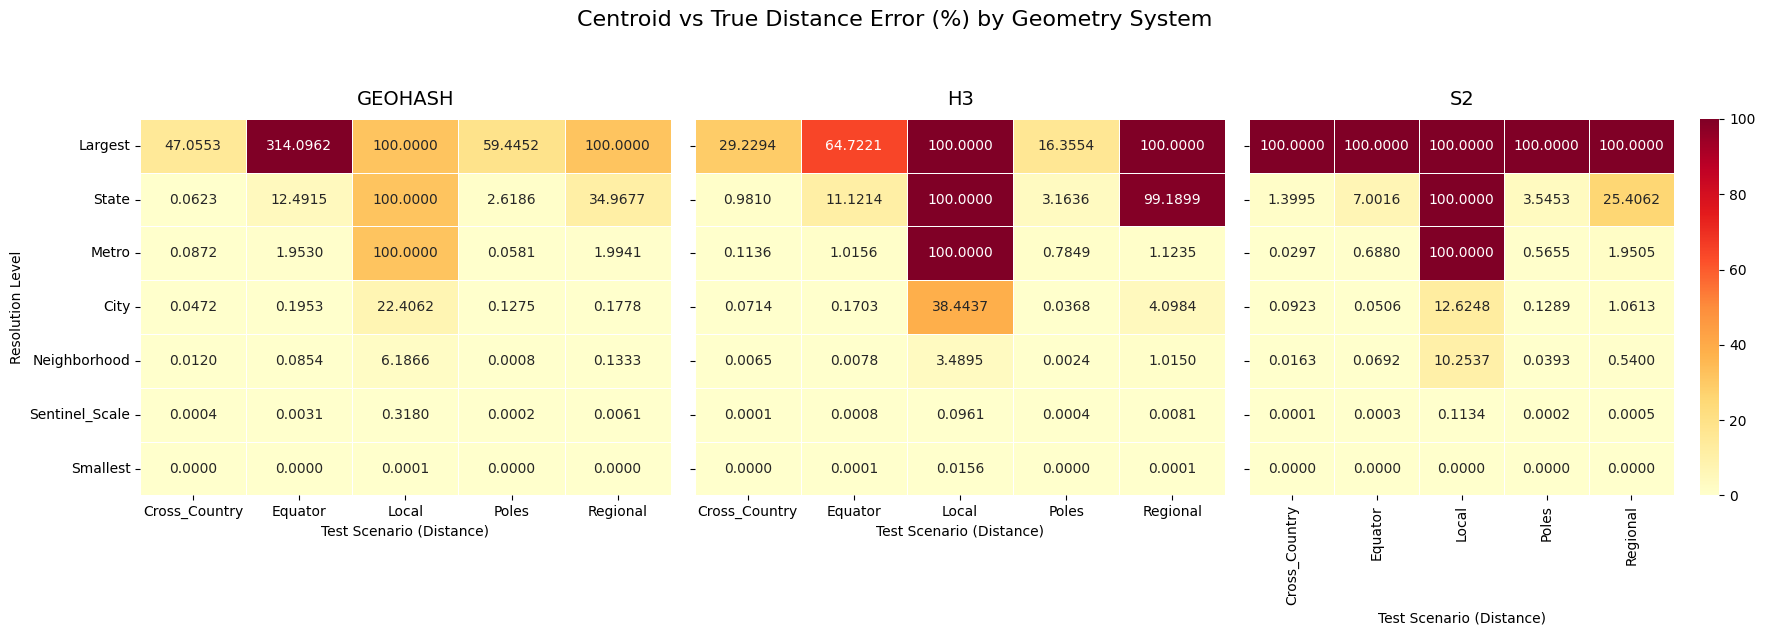

In [23]:
systems = ['GEOHASH', 'H3', 'S2']
level_order = ["Largest", "State", "Metro", "City", "Neighborhood", "Sentinel_Scale", "Smallest"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("Centroid vs True Distance Error (%) by Geometry System", fontsize=16, y=1.05)

for i, sys in enumerate(systems):
    sys_df = point_to_point_matrix[point_to_point_matrix['System'] == sys]
    pivot_df = sys_df.pivot(index="Level", columns="Scenario", values="Centroid_vs_True_Err_%")
    pivot_df = pivot_df.reindex(level_order)
    sns.heatmap(
        pivot_df, 
        ax=axes[i], 
        annot=True,          
        fmt=".4f",           
        cmap="YlOrRd",       
        cbar=(i == 2),       
        linewidths=.5
    )
    
    axes[i].set_title(f"{sys}", fontsize=14, pad=10)
    axes[i].set_xlabel("Test Scenario (Distance)")
    axes[i].set_ylabel("Resolution Level" if i == 0 else "")

plt.tight_layout()
plt.show()

#### Visualization

In [24]:
from ipywidgets import HBox, Output

def plot_side_by_side_staircase(start, end, title="Path"):
    # Generate path points
    lats = np.linspace(start[0], end[0], 100)
    lons = np.linspace(start[1], end[1], 100)
    path = list(zip(lats, lons))
    
    mid_lat = (start[0] + end[0]) / 2
    mid_lon = (start[1] + end[1]) / 2
    
    # ---------------------------------------------------------
    # 1. GEOHASH MAP 
    # ---------------------------------------------------------
    m_gh = folium.Map(location=[mid_lat, mid_lon], zoom_start=9, tiles="CartoDB positron")
    folium.PolyLine(locations=path, color="black", weight=4, opacity=0.8).add_to(m_gh)
    
    gh_intersected = set(geohash.encode(la, lo, precision=5) for la, lo in path)
    for token in gh_intersected:
        lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(token)
        n, s_ = lat_c + lat_err, lat_c - lat_err
        e, w_ = lon_c + lon_err, lon_c - lon_err
        poly = [[s_, w_], [s_, e], [n, e], [n, w_]]
        folium.Polygon(locations=poly, color='blue', weight=1, fill=True, fill_opacity=0.4).add_to(m_gh)
        
    # ---------------------------------------------------------
    # 2. H3 MAP 
    # ---------------------------------------------------------
    m_h3 = folium.Map(location=[mid_lat, mid_lon], zoom_start=9, tiles="CartoDB positron")
    folium.PolyLine(locations=path, color="black", weight=4, opacity=0.8).add_to(m_h3)
    
    h3_intersected = set(h3.latlng_to_cell(la, lo, 6) for la, lo in path)
    for cell in h3_intersected:
        poly = [list(c) for c in h3.cell_to_boundary(cell)]
        folium.Polygon(locations=poly, color='green', weight=1, fill=True, fill_opacity=0.4).add_to(m_h3)

    # ---------------------------------------------------------
    # 3. S2 MAP 
    # ---------------------------------------------------------
    m_s2 = folium.Map(location=[mid_lat, mid_lon], zoom_start=9, tiles="CartoDB positron")
    folium.PolyLine(locations=path, color="black", weight=4, opacity=0.8).add_to(m_s2)
    
    s2_intersected = set(s2.CellId.from_lat_lng(s2.LatLng.from_degrees(la, lo)).parent(11) for la, lo in path)
    for cid in s2_intersected:
        cell = s2.Cell(cid)
        poly = [[s2.LatLng.from_point(cell.get_vertex(i)).lat().degrees, 
                 s2.LatLng.from_point(cell.get_vertex(i)).lng().degrees] for i in range(4)]
        folium.Polygon(locations=poly, color='red', weight=1, fill=True, fill_opacity=0.4).add_to(m_s2)

    # ---------------------------------------------------------
    # Display the Maps Side-by-Side  
    # ---------------------------------------------------------
    print(f"=== {title} Quantization Comparison ===")
    print(f"Geohash (Blue) | H3 (Green) | S2 (Red)")
    
    out_gh = Output(layout={'width': '33%'})
    out_h3 = Output(layout={'width': '33%'})
    out_s2 = Output(layout={'width': '33%'})
    
    with out_gh:
        display(m_gh)
    with out_h3:
        display(m_h3)
    with out_s2:
        display(m_s2)
        
    display(HBox([out_gh, out_h3, out_s2]))


In [25]:
distance_level_selected = "regional"
pair_selected = test_pairs[distance_level_selected]
start_loc = pair_selected[0]
end_loc = pair_selected[1]

plot_side_by_side_staircase(start_loc, end_loc, title="Regional")

=== Regional Quantization Comparison ===
Geohash (Blue) | H3 (Green) | S2 (Red)


In [26]:
path_start = pair_selected[0]
path_end = pair_selected[1]


def sample_path(start, end, num_points=60):
    lat1, lon1 = start
    lat2, lon2 = end
    lats = np.linspace(lat1, lat2, num_points)
    lons = np.linspace(lon1, lon2, num_points)
    return list(zip(lats, lons))


def path_cell_intersections(path, selected_level="city"):
    cfg = levels[selected_level]

    gh_tokens = set()
    h3_tokens = set()
    s2_tokens = set()

    for la, lo in path:
        gh_tokens.add(geohash.encode(la, lo, precision=cfg["geohash"]))
        h3_tokens.add(h3.latlng_to_cell(la, lo, cfg["h3"]))
        ll = s2.LatLng.from_degrees(la, lo)
        cid = s2.CellId.from_lat_lng(ll).parent(cfg["s2"])
        s2_tokens.add(cid.to_token())

    def build_geohash_cells(tokens):
        cells = []
        for token in tokens:
            lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(token)
            n, s_ = lat_c + lat_err, lat_c - lat_err
            e, w_ = lon_c + lon_err, lon_c - lon_err
            vertices = [[s_, w_], [s_, e], [n, e], [n, w_]]
            cells.append({"token": token, "vertices": vertices})
        return cells

    def build_h3_cells(tokens):
        cells = []
        for idx in tokens:
            vertices = [list(coord) for coord in h3.cell_to_boundary(idx)]
            cells.append({"token": idx, "vertices": vertices})
        return cells

    def build_s2_cells(tokens):
        cells = []
        for token in tokens:
            cid = s2.CellId.from_token(token)
            cell = s2.Cell(cid)
            vertices = [
                [s2.LatLng.from_point(cell.get_vertex(i)).lat().degrees,
                 s2.LatLng.from_point(cell.get_vertex(i)).lng().degrees]
                for i in range(4)
            ]
            cells.append({"token": token, "vertices": vertices})
        return cells

    return {
        "path": path,
        "geohash_cells": build_geohash_cells(gh_tokens),
        "h3_cells": build_h3_cells(h3_tokens),
        "s2_cells": build_s2_cells(s2_tokens),
    }


def plot_path_intersections(selected_level="city"):
    path = sample_path(path_start, path_end, num_points=80)
    data = path_cell_intersections(path, selected_level)

    m = folium.Map(location=[(path_start[0] + path_end[0]) / 2, (path_start[1] + path_end[1]) / 2], tiles="OpenStreetMap")

    # Draw the path
    folium.PolyLine(locations=[[la, lo] for la, lo in path], color="black", weight=3, opacity=0.7, tooltip="Path").add_to(m)

    # Draw intersected cells
    fg_gh = folium.FeatureGroup(name="Geohash cells along path").add_to(m)
    for cell in data["geohash_cells"]:
        folium.Polygon(locations=cell["vertices"], color="blue", weight=1, fill=False).add_to(fg_gh)

    fg_h3 = folium.FeatureGroup(name="H3 cells along path").add_to(m)
    for cell in data["h3_cells"]:
        folium.Polygon(locations=cell["vertices"], color="green", weight=1, fill=False).add_to(fg_h3)

    fg_s2 = folium.FeatureGroup(name="S2 cells along path").add_to(m)
    for cell in data["s2_cells"]:
        folium.Polygon(locations=cell["vertices"], color="red", weight=1, fill=False).add_to(fg_s2)

    # Fit to the path
    m.fit_bounds([[min(p[0] for p in path), min(p[1] for p in path)],
                  [max(p[0] for p in path), max(p[1] for p in path)]])

    folium.LayerControl().add_to(m)
    return m

path_map = plot_path_intersections("city")
display(path_map)

## Quantization - Point to Cell

Quantization error - cell centroid distance - If we are putting a cell around a lat/lon - how far is the cell center from the lat lon

In [26]:
print(f"Lat: {lat}, Lon: {lon}")

selected_level = "smallest"
result_smallest = get_cell(lat, lon, selected_level=selected_level)

# Geohash Distance
gh_dist_m = haversine_dist_m(lat, lon, result_smallest["geohash"]["centroid"][0], result_smallest["geohash"]["centroid"][1])
print(f"Geohash '{selected_level}' Off-Center Distance:  {gh_dist_m:.2f} meters")

# H3 Distance
h3_dist_m = haversine_dist_m(lat, lon, result_smallest["h3"]["centroid"][0], result_smallest["h3"]["centroid"][1])
print(f"H3 '{selected_level}' Off-Center Distance:       {h3_dist_m:.2f} meters")

# S2 Distance
s2_dist_m = haversine_dist_m(lat, lon, result_smallest["s2"]["centroid"][0], result_smallest["s2"]["centroid"][1])
print(f"S2 '{selected_level}' Off-Center Distance:       {s2_dist_m:.2f} meters")

Lat: 45.428, Lon: -75.718
Geohash 'smallest' Off-Center Distance:  0.01 meters
H3 'smallest' Off-Center Distance:       0.52 meters
S2 'smallest' Off-Center Distance:       0.00 meters


In [55]:
selected_level = "city"
result_smallest = get_cell(lat, lon, selected_level=selected_level)

# Geohash Distance
gh_dist_m = haversine_dist_m(lat, lon, result_smallest["geohash"]["centroid"][0], result_smallest["geohash"]["centroid"][1])
print(f"Geohash '{selected_level}' Off-Center Distance:  {gh_dist_m:.2f} meters")

# H3 Distance
h3_dist_m = haversine_dist_m(lat, lon, result_smallest["h3"]["centroid"][0], result_smallest["h3"]["centroid"][1])
print(f"H3 '{selected_level}' Off-Center Distance:       {h3_dist_m:.2f} meters")

# S2 Distance
s2_dist_m = haversine_dist_m(lat, lon, result_smallest["s2"]["centroid"][0], result_smallest["s2"]["centroid"][1])
print(f"S2 '{selected_level}' Off-Center Distance:       {s2_dist_m:.2f} meters")

Geohash 'city' Off-Center Distance:  2061.21 meters
H3 'city' Off-Center Distance:       3622.33 meters
S2 'city' Off-Center Distance:       1806.92 meters


## Intersection -  Point to Polygon

In [28]:
geofence_poly = [ #downtown ottawa - bounding box
    [45.430, -75.715],
    [45.432, -75.695],
    [45.418, -75.690],
    [45.415, -75.705],
    [45.430, -75.715] 
]

test_points = {
    "Inside": (45.422, -75.700),
    "Borderline": (45.430, -75.710),
    "Outside": (45.410, -75.720)
}

In [29]:
from shapely.geometry import Point, Polygon

level_name = "neighborhood"
config = levels[level_name]
gh_precision = config["geohash"]
h3_res = config["h3"]
s2_level = config["s2"]

# Exact Shapely Geometry
shapely_geofence = Polygon([(lon, lat) for lat, lon in geofence_poly])

# H3 Native Polyfill (h3-py v4+)
h3_poly = h3.LatLngPoly(geofence_poly)
h3_set = set(h3.polygon_to_cells(h3_poly, h3_res))

# S2 Native Bounding Box Polyfill 
lats, lons = zip(*geofence_poly)
sw = s2.LatLng.from_degrees(min(lats), min(lons))
ne = s2.LatLng.from_degrees(max(lats), max(lons))
rect = s2.LatLngRect.from_point_pair(sw, ne)

coverer = s2.RegionCoverer()
coverer.min_level = s2_level
coverer.max_level = s2_level
s2_covering = coverer.get_covering(rect)

s2_set = set()
for cid in s2_covering:
    cell = s2.Cell(cid)
    vertices = [(s2.LatLng.from_point(cell.get_vertex(i)).lng().degrees, 
                 s2.LatLng.from_point(cell.get_vertex(i)).lat().degrees) for i in range(4)]
    if shapely_geofence.intersects(Polygon(vertices)):
        s2_set.add(cid.to_token())

# Geohash Grid Polyfill 
gh_set = set()
_, _, lat_err, lon_err = geohash.decode_exactly(geohash.encode(geofence_poly[0][0], geofence_poly[0][1], gh_precision))

for lat_p in np.arange(min(lats), max(lats) + lat_err*2, lat_err*2):
    for lon_p in np.arange(min(lons), max(lons) + lon_err*2, lon_err*2):
        token = geohash.encode(lat_p, lon_p, gh_precision)
        n, s_ = lat_p + lat_err, lat_p - lat_err
        e, w_ = lon_p + lon_err, lon_p - lon_err
        cell_poly = Polygon([(w_, s_), (e, s_), (e, n), (w_, n), (w_, s_)])
        if shapely_geofence.intersects(cell_poly):
            gh_set.add(token)

results = []

for point_name, (pt_lat, pt_lon) in test_points.items():
    row = {"Point_Type": point_name, "Lat_Lon": f"{pt_lat}, {pt_lon}"}
    
    # --- Ground Truth: Exact Shapely Contains ---
    pt = Point(pt_lon, pt_lat)
    start = time.perf_counter()
    row["Exact_Contains"] = shapely_geofence.contains(pt)
    row["Exact_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)
    
    # Retrieve cell vertices for dynamic geometric intersection evaluation
    result_cell = get_cell(pt_lat, pt_lon, level_name)
    
    # --------------------------------------
    # GEOHASH EVALUATION
    # --------------------------------------
    # Native Set Lookup
    start = time.perf_counter()
    gh_token = geohash.encode(pt_lat, pt_lon, gh_precision)
    row["GEOHASH_In_Set"] = gh_token in gh_set
    row["GEOHASH_Set_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)
    
    # Dynamic Geometric Intersects
    gh_poly = Polygon([(lon, lat) for lat, lon in result_cell['geohash']['vertices']])
    start = time.perf_counter()
    row["GEOHASH_Intersects"] = gh_poly.intersects(shapely_geofence)
    row["GEOHASH_Intersect_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)
    
    # --------------------------------------
    # H3 EVALUATION
    # --------------------------------------
    # Native Set Lookup
    start = time.perf_counter()
    h3_token = h3.latlng_to_cell(pt_lat, pt_lon, h3_res)
    row["H3_In_Set"] = h3_token in h3_set
    row["H3_Set_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)
    
    # Dynamic Geometric Intersects
    h3_poly = Polygon([(lon, lat) for lat, lon in result_cell['h3']['vertices']])
    start = time.perf_counter()
    row["H3_Intersects"] = h3_poly.intersects(shapely_geofence)
    row["H3_Intersect_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)
    
    # --------------------------------------
    # S2 EVALUATION
    # --------------------------------------
    # Native Set Lookup
    start = time.perf_counter()
    s2_token = s2.CellId.from_lat_lng(s2.LatLng.from_degrees(pt_lat, pt_lon)).parent(s2_level).to_token()
    row["S2_In_Set"] = s2_token in s2_set
    row["S2_Set_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)
    
    # Dynamic Geometric Intersects
    s2_poly = Polygon([(lon, lat) for lat, lon in result_cell['s2']['vertices']])
    start = time.perf_counter()
    row["S2_Intersects"] = s2_poly.intersects(shapely_geofence)
    row["S2_Intersect_Time_ms"] = round((time.perf_counter() - start) * 1000, 5)

    results.append(row)

# DISPLAY
intersection_matrix = pd.DataFrame(results)

# Rearrange columns so outputs are grouped by Truth -> Set Lookups -> Intersections -> Timings
cols = (
    ['Point_Type', 'Lat_Lon', 'Exact_Contains'] + 
    ['GEOHASH_In_Set', 'H3_In_Set', 'S2_In_Set'] + 
    ['GEOHASH_Intersects', 'H3_Intersects', 'S2_Intersects'] + 
    ['Exact_Time_ms'] +
    ['GEOHASH_Set_Time_ms', 'H3_Set_Time_ms', 'S2_Set_Time_ms'] +
    ['GEOHASH_Intersect_Time_ms', 'H3_Intersect_Time_ms', 'S2_Intersect_Time_ms']
)
intersection_matrix = intersection_matrix[cols]

display(intersection_matrix)

,Point_Type,Lat_Lon,Exact_Contains,GEOHASH_In_Set,H3_In_Set,S2_In_Set,GEOHASH_Intersects,H3_Intersects,S2_Intersects,Exact_Time_ms,GEOHASH_Set_Time_ms,H3_Set_Time_ms,S2_Set_Time_ms,GEOHASH_Intersect_Time_ms,H3_Intersect_Time_ms,S2_Intersect_Time_ms
0,Inside,"45.422, -75.7",True,True,True,True,True,True,True,0.0193,0.0059,0.0031,0.0143,0.0065,0.0149,0.0054
1,Borderline,"45.43, -75.71",True,True,False,True,True,True,True,0.0053,0.0054,0.0018,0.0142,0.0046,0.0063,0.0050
2,Outside,"45.41, -75.72",False,False,False,True,False,False,True,0.0500,0.0065,0.0030,0.0160,0.0064,0.0068,0.0082


### Visualization

In [30]:
def visualize_pip_geometries(geofence_poly, test_points, gh_set, h3_set, s2_set):
    # Center map roughly around Downtown Ottawa
    mid_lat = sum(p[0] for p in geofence_poly) / len(geofence_poly)
    mid_lon = sum(p[1] for p in geofence_poly) / len(geofence_poly)
    
    m = folium.Map(location=[mid_lat, mid_lon], zoom_start=14, tiles="CartoDB positron")

    # Plot the Ground Truth Geofence
    folium.Polygon(
        locations=geofence_poly, 
        color="black", 
        weight=4, 
        fill=False, 
        tooltip="Exact Geofence"
    ).add_to(m)

    # Plot the Test Points
    colors = {"Inside": "green", "Borderline": "orange", "Outside": "red"}
    for name, (pt_lat, pt_lon) in test_points.items():
        folium.Marker(
            [pt_lat, pt_lon], 
            popup=f"{name} Point", 
            tooltip=name,
            icon=folium.Icon(color=colors[name], icon="info-sign")
        ).add_to(m)

    # Create Toggleable Feature Groups for each Index
    fg_gh = folium.FeatureGroup(name="Geohash Covering (Blue)", show=False)
    fg_h3 = folium.FeatureGroup(name="H3 Covering (Green)", show=False) # Default visible
    fg_s2 = folium.FeatureGroup(name="S2 Covering (Red)", show=False)

    # --- Add Geohash Cells ---
    for token in gh_set:
        lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(token)
        n, s_ = lat_c + lat_err, lat_c - lat_err
        e, w_ = lon_c + lon_err, lon_c - lon_err
        poly = [[s_, w_], [s_, e], [n, e], [n, w_], [s_, w_]]
        folium.Polygon(locations=poly, color='blue', weight=1, fill=True, fill_opacity=0.3).add_to(fg_gh)

    # --- Add H3 Cells ---
    for token in h3_set:
        # h3 returns (lat, lon) which is what Folium expects
        poly = h3.cell_to_boundary(token) 
        folium.Polygon(locations=poly, color='green', weight=2, fill=True, fill_opacity=0.3).add_to(fg_h3)

    # --- Add S2 Cells ---
    for token in s2_set:
        cell = s2.Cell(s2.CellId.from_token(token))
        poly = [[s2.LatLng.from_point(cell.get_vertex(i)).lat().degrees,
                 s2.LatLng.from_point(cell.get_vertex(i)).lng().degrees] for i in range(4)]
        folium.Polygon(locations=poly, color='red', weight=2, fill=True, fill_opacity=0.3).add_to(fg_s2)

    # Add layers to map
    fg_gh.add_to(m)
    fg_h3.add_to(m)
    fg_s2.add_to(m)
    
    # Add Layer Control to allow toggling
    folium.LayerControl(collapsed=False).add_to(m)

    return m

# Render the map
pip_map = visualize_pip_geometries(geofence_poly, test_points, gh_set, h3_set, s2_set)
display(pip_map)

## Neighborhood

In [31]:
cfg = levels["neighborhood"]

In [32]:
# since pygeohash doesnt have inherent neighbors function
def get_gh_vertices(token):
    lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(token)
    n, s_ = lat_c + lat_err, lat_c - lat_err
    e, w_ = lon_c + lon_err, lon_c - lon_err
    return [[s_, w_], [s_, e], [n, e], [n, w_], [s_, w_]]


def get_geohash_neighbors(token):
    lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(token)
    
    # The step size to the next cell is exactly its width/height
    lat_step = lat_err * 2
    lon_step = lon_err * 2
    
    neighbors = []
    # Loop through the 3x3 grid around the center
    for d_lat in [-lat_step, 0, lat_step]:
        for d_lon in [-lon_step, 0, lon_step]:
            if d_lat == 0 and d_lon == 0:
                continue # Skip the center itself
            
            # Encode the newly shifted center point
            n_token = geohash.encode(lat_c + d_lat, lon_c + d_lon, len(token))
            neighbors.append(n_token)
            
    return set(neighbors)

In [33]:
def get_neighbors(lat, lon, level):
    cfg = levels[level]
    gh_center = geohash.encode(lat, lon, precision=cfg["geohash"])
    gh_neighbors = get_geohash_neighbors(gh_center)

    h3_center = h3.latlng_to_cell(lat, lon, cfg["h3"])
    h3_disk = list(h3.grid_disk(h3_center, k=1)) #grid_disk with k=1 returns the center plus its immediate ring of neighbors

    s2_center = s2.CellId.from_lat_lng(s2.LatLng.from_degrees(lat, lon)).parent(cfg["s2"])
    s2_neighbors = s2_center.get_all_neighbors(cfg["s2"]) # get_all_neighbors returns the 4 edge neighbors and 4 vertex (corner) neighbors

    return {
        "gh_center": gh_center,
        "gh_neighbors": gh_neighbors,

        "h3_center": h3_center,
        "h3_neighbors": h3_disk,

        "s2_center": s2_center,
        "s2_neighbors": s2_neighbors
    }

In [34]:
centers_and_neighbors = get_neighbors(lat, lon, level="neighborhood")

#### Visualize

In [35]:
def get_s2_vertices(cell_id):
    cell = s2.Cell(cell_id)
    return [[s2.LatLng.from_point(cell.get_vertex(i)).lat().degrees,
             s2.LatLng.from_point(cell.get_vertex(i)).lng().degrees] for i in range(4)]

In [36]:
def visualize_neighborhoods(lat, lon, centers_and_neighbors):
    m = folium.Map(location=[lat, lon], zoom_start=14, tiles="CartoDB positron")
    folium.Marker([lat, lon], popup="Target Point", icon=folium.Icon(color="black")).add_to(m)

    # Plot Geohash
    fg_gh = folium.FeatureGroup(name="Geohash Neighbors (Blue)", show=False)
    gh_center = centers_and_neighbors["gh_center"]
    gh_neighbors = centers_and_neighbors["gh_neighbors"]
    
    folium.Polygon(locations=get_gh_vertices(gh_center), color="blue", weight=4, fill=True, fill_opacity=0.4).add_to(fg_gh)
    for token in gh_neighbors:
        folium.Polygon(locations=get_gh_vertices(token), color="blue", weight=1, fill=True, fill_opacity=0.1).add_to(fg_gh)

    # Plot H3
    fg_h3 = folium.FeatureGroup(name="H3 Neighbors (Green)", show=True) # Default visible
    h3_center = centers_and_neighbors["h3_center"]
    h3_neighbors = centers_and_neighbors["h3_neighbors"]
    
    for token in h3_neighbors:
        poly = h3.cell_to_boundary(token)
        if token == h3_center:
            folium.Polygon(locations=poly, color="green", weight=4, fill=True, fill_opacity=0.4).add_to(fg_h3)
        else:
            folium.Polygon(locations=poly, color="green", weight=1, fill=True, fill_opacity=0.1).add_to(fg_h3)

    # Plot S2
    fg_s2 = folium.FeatureGroup(name="S2 Neighbors (Red)", show=False)
    s2_center = centers_and_neighbors["s2_center"]
    s2_neighbors = centers_and_neighbors["s2_neighbors"]
    
    folium.Polygon(locations=get_s2_vertices(s2_center), color="red", weight=4, fill=True, fill_opacity=0.4).add_to(fg_s2)
    for cid in s2_neighbors:
        folium.Polygon(locations=get_s2_vertices(cid), color="red", weight=1, fill=True, fill_opacity=0.1).add_to(fg_s2)

    fg_gh.add_to(m)
    fg_h3.add_to(m)
    fg_s2.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    return m

In [60]:
neighborhood_map = visualize_neighborhoods(lat, lon, centers_and_neighbors)
display(neighborhood_map)

## Hierarchy & Coverage

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from shapely.geometry import Polygon
from shapely.prepared import prep
from pyproj import Geod

geofence_coords = [
    [45.430, -75.715], [45.432, -75.695], [45.418, -75.690], 
    [45.415, -75.705], [45.430, -75.715]
]
shapely_geofence = Polygon([(lon, lat) for lat, lon in geofence_coords])

# Prepare geometry for C-level intersection speedups
prepared_geofence = prep(shapely_geofence)

geod = Geod(ellps="WGS84")
TRUE_AREA_SQM, _ = geod.geometry_area_perimeter(shapely_geofence)
TRUE_AREA_SQM = abs(TRUE_AREA_SQM)

def get_geohash_area(token):
    lat_c, lon_c, lat_err, lon_err = geohash.decode_exactly(token)
    width_m = (lon_err * 2) * math.cos(math.radians(lat_c)) * 111320.0
    height_m = (lat_err * 2) * 111320.0
    return width_m * height_m

def build_geojson(polys, color):
    return {
        "type": "FeatureCollection",
        "features": [{"type": "Feature", "geometry": {"type": "Polygon", "coordinates": [p]}} for p in polys]
    }

# UI 
out_metrics = widgets.Output()
out_map_gh = widgets.Output()
out_map_h3 = widgets.Output()
out_map_s2 = widgets.Output()

def explore_hierarchy(gh_prec, h3_res, s2_level):
    min_lon, min_lat, max_lon, max_lat = shapely_geofence.bounds

    # Geohash 
    gh_cells, gh_polys = [], []
    _, _, lat_err, lon_err = geohash.decode_exactly(geohash.encode(min_lat, min_lon, gh_prec))
    lat_step, lon_step = lat_err * 2, lon_err * 2
    
    for lat_p in np.arange(min_lat, max_lat + lat_step, lat_step):
        for lon_p in np.arange(min_lon, max_lon + lon_step, lon_step):
            n, s_ = lat_p + lat_err, lat_p - lat_err
            e, w_ = lon_p + lon_err, lon_p - lon_err
            cell_poly = Polygon([(w_, s_), (e, s_), (e, n), (w_, n), (w_, s_)])
            if prepared_geofence.intersects(cell_poly): # Using prepared geometry for 10x-100x faster checks
                gh_cells.append(geohash.encode(lat_p, lon_p, gh_prec))
                gh_polys.append([[w_, s_], [e, s_], [e, n], [w_, n], [w_, s_]])
                
    # H3
    h3_cells = h3.polygon_to_cells(h3.LatLngPoly(geofence_coords), h3_res)
    h3_polys = [[ [lon, lat] for lat, lon in h3.cell_to_boundary(c) ] + [[h3.cell_to_boundary(c)[0][1], h3.cell_to_boundary(c)[0][0]]] for c in h3_cells]
    
    # S2
    coverer = s2.RegionCoverer()
    coverer.min_level, coverer.max_level = s2_level, s2_level
    s2_covering = coverer.get_covering(s2.LatLngRect.from_point_pair(
        s2.LatLng.from_degrees(min_lat, min_lon), s2.LatLng.from_degrees(max_lat, max_lon)
    ))
    
    s2_cells, s2_polys = [], []
    for cid in s2_covering:
        cell = s2.Cell(cid)
        v = [[s2.LatLng.from_point(cell.get_vertex(i)).lng().degrees, s2.LatLng.from_point(cell.get_vertex(i)).lat().degrees] for i in range(4)]
        v.append(v[0])
        if prepared_geofence.intersects(Polygon(v)):
            s2_cells.append(cid)
            s2_polys.append(v)

    # Metrics
    gh_area = sum(get_geohash_area(c) for c in gh_cells)
    h3_area = sum(h3.cell_area(c, unit='m^2') for c in h3_cells)
    s2_area = sum(s2.Cell(c).exact_area() * (6371000 ** 2) for c in s2_cells)

    metrics = pd.DataFrame({
        "Geometry": ["Geohash", "H3", "S2"],
        "Resolution": [gh_prec, h3_res, s2_level],
        "Cell Count": [len(gh_cells), len(h3_cells), len(s2_cells)],
        "Covering Area (m²)": [f"{gh_area:,.0f}", f"{h3_area:,.0f}", f"{s2_area:,.0f}"],
        "Over-coverage (%)": [
            f"{((gh_area/TRUE_AREA_SQM)-1)*100:.1f}%",
            f"{((h3_area/TRUE_AREA_SQM)-1)*100:.1f}%" if h3_area > 0 else "N/A",
            f"{((s2_area/TRUE_AREA_SQM)-1)*100:.1f}%"
        ]
    })
    
    with out_metrics:
        clear_output(wait=True)
        print(f"EXACT GEOFENCE AREA: {TRUE_AREA_SQM:,.0f} m²")
        display(metrics)

    # UI
    mid_lat, mid_lon = (min_lat + max_lat) / 2, (min_lon + max_lon) / 2

    def create_map(geojson_data, color):
        m = folium.Map(location=[mid_lat, mid_lon], zoom_start=13, tiles="CartoDB positron", width=300, height=350)
        folium.Polygon(locations=geofence_coords, color="black", weight=2, fill=False).add_to(m)
        folium.GeoJson(geojson_data, style_function=lambda x, c=color: {'fillColor': c, 'color': c, 'weight': 1, 'fillOpacity': 0.3}).add_to(m)
        return m

    with out_map_gh:
        clear_output(wait=True)
        display(create_map(build_geojson(gh_polys, 'blue'), 'blue'))
    with out_map_h3:
        clear_output(wait=True)
        display(create_map(build_geojson(h3_polys, 'green'), 'green'))
    with out_map_s2:
        clear_output(wait=True)
        display(create_map(build_geojson(s2_polys, 'red'), 'red'))
style = {'description_width': 'initial'}

slider_gh = widgets.IntSlider(min=5, max=9, step=1, value=7, description='Geohash Prec:', style=style, continuous_update=False)
slider_h3 = widgets.IntSlider(min=6, max=12, step=1, value=9, description='H3 Res:', style=style, continuous_update=False)
slider_s2 = widgets.IntSlider(min=11, max=18, step=1, value=14, description='S2 Level:', style=style, continuous_update=False)

widgets.interactive_output(explore_hierarchy, {'gh_prec': slider_gh, 'h3_res': slider_h3, 's2_level': slider_s2})

map_box = widgets.HBox([out_map_gh, out_map_h3, out_map_s2])
display(widgets.VBox([widgets.HBox([slider_gh, slider_h3, slider_s2]), out_metrics, map_box]))